In [38]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd
from src.DB import get_engine,query
from src.logger import setup_logging,get_logger
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats
setup_logging()
log = get_logger(__name__)


plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e5e5e5",
    "grid.linewidth":    0.7,
    "font.size":         11,
})



In [2]:
plt.rcParams.update({
    "figure.dpi":       120,
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,   
    "axes.spines.right":False,   
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "legend.fontsize":  9,
    "legend.frameon":   False,
    "grid.color":       "#E5E5E5",
    "grid.linewidth":   0.6,
})

# ── Shared colour palette ─────────────────────────────────────────────────────
C = {
    "blue":   "#4878CF",
    "green":  "#6ACC65",
    "red":    "#D65F5F",
    "purple": "#B47CC7",
    "orange": "#E07B39",
    "grey":   "#AAAAAA",
}

In [3]:
df = query(
    "SELECT d.calendar_year, d.calendar_month, COUNT(*) AS play_count, "
    "round(SUM(f.ms_played) / 60000.0, 2) AS minutes_listened "
    "FROM fact_listening_history AS f "
    "JOIN dim_date d ON f.date_key = d.date_key "
    "GROUP BY d.calendar_year, d.calendar_month "
    "ORDER BY d.calendar_year, d.calendar_month;"
)
df.head()

09:40:39  INFO      Database engine initialized


,calendar_year,calendar_month,play_count,minutes_listened
0,2020,12,541,1461.43
1,2021,1,325,895.06
2,2021,2,746,1972.19
3,2021,3,402,1196.19
4,2021,4,812,2190.42


In [4]:
df["period"] = pd.to_datetime(
    df["calendar_year"].astype(str) + "-" + df["calendar_month"].astype(str).str.zfill(2)
)
df = df.sort_values("period")

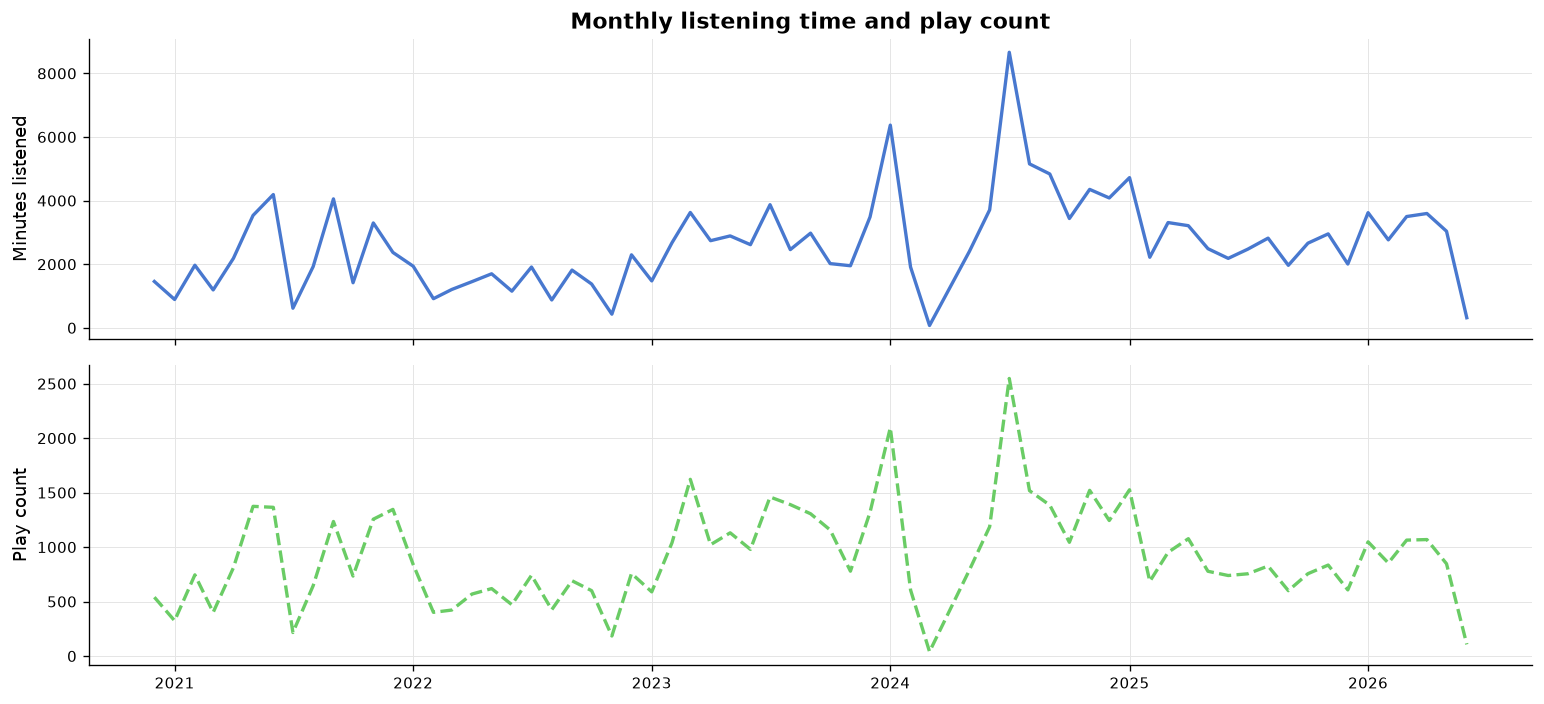

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

ax1.plot(df["period"], df["minutes_listened"], color=C["blue"], linewidth=2)
ax1.set_ylabel("Minutes listened")
ax1.set_title("Monthly listening time and play count")

ax2.plot(df["period"], df["play_count"], color=C["green"], linewidth=2, linestyle="--")
ax2.set_ylabel("Play count")

plt.tight_layout()
plt.show()

the line shows clear upward patter at the beginning then it slowly declines in 2022 the final year of my college then the pace get up again as im finishing the first semester and it continues back up till the middle of 2024 then as I began my job it declines back and keeps that pace till now

In [6]:
df2 = query("select f.played_at,EXTRACT(HOUR from f.played_at) as play_hour,d.weekday_name,sum(f.ms_played)/60000 as minutes_listened" \
" from fact_listening_history f" \
" join dim_date d on d.date_key = f.date_key" \
" group by f.played_at,d.weekday_name")

df2

,played_at,play_hour,weekday_name,minutes_listened
0,2023-03-02 21:00:29,21,Thursday,1
1,2024-09-28 03:15:39,3,Saturday,3
2,2023-09-08 19:42:35,19,Friday,0
3,2024-01-15 05:00:37,5,Monday,3
4,2026-04-09 14:53:09,14,Thursday,3
...,...,...,...,...
57305,2025-11-15 08:39:52,8,Saturday,3
57306,2025-10-02 00:24:19,0,Thursday,2
57307,2026-02-06 11:15:03,11,Friday,1
57308,2024-06-26 23:40:32,23,Wednesday,3


In [7]:
pivot = df2.pivot_table(index= "weekday_name" , columns= "play_hour" , values= "minutes_listened" , aggfunc= "sum",fill_value= 0
)

weekday_order = [
    "Sunday",
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday"
]

pivot = pivot.reindex(weekday_order)

In [37]:
pivot

play_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday_name,,,,,,,,,,,,,,,,,,,,,
Sunday,1124,720,830,805,711,562,1078,961,810,707,...,691,1156,1050,874,969,917,921,1194,1046,1149
Monday,1136,1229,1027,957,801,591,605,760,593,586,...,748,694,1520,715,666,919,1064,958,1190,1141
Tuesday,1007,1003,890,882,947,762,859,918,673,783,...,722,908,1140,914,853,1048,1188,1141,1190,1258
Wednesday,1090,1269,740,630,755,741,958,1112,699,673,...,927,1030,980,945,844,1080,1293,1090,909,877
Thursday,1260,939,711,749,580,476,776,852,664,419,...,1014,1232,1242,1151,905,700,896,1101,1008,1321
Friday,995,809,764,799,673,608,621,976,619,466,...,686,915,1382,866,931,983,1304,1144,1322,976
Saturday,995,861,1063,886,761,743,928,1147,934,422,...,1260,1591,1576,1383,888,1428,1196,1159,1231,1137


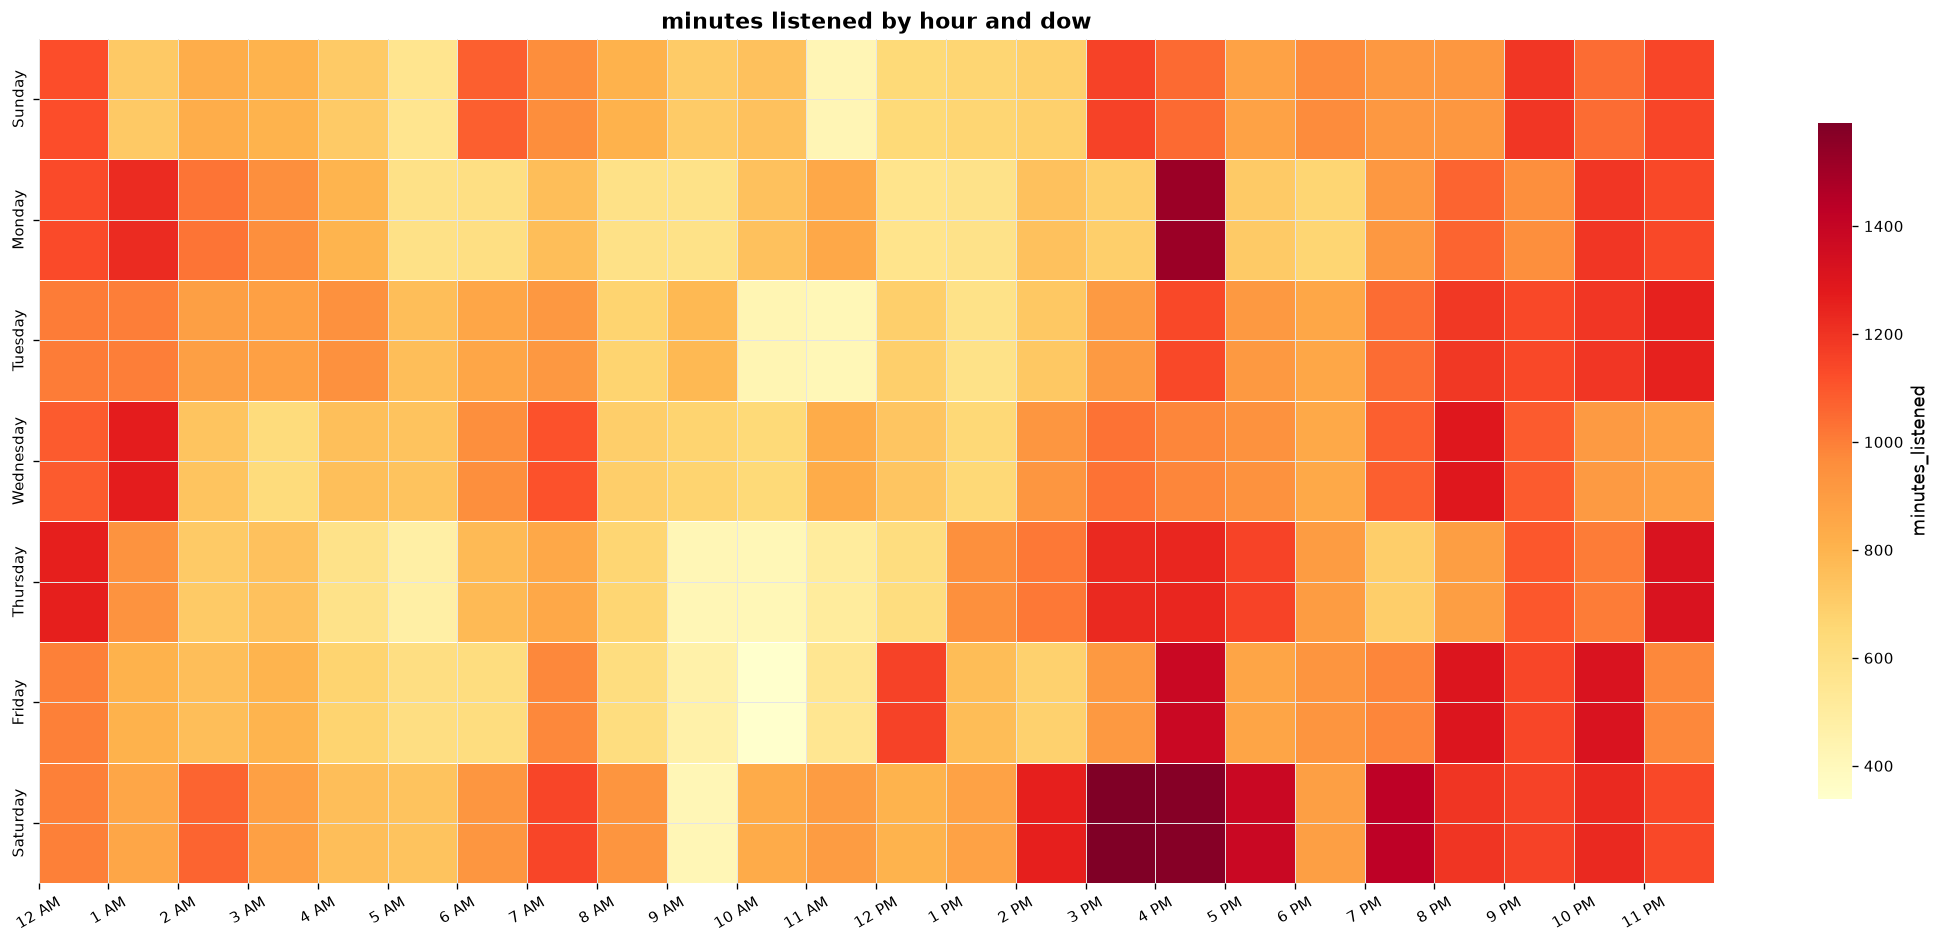

In [8]:
pivot = pivot.astype(int)
fig, ax = plt.subplots(figsize=(18, 8))

sns.heatmap(
    pivot,
    ax=ax,
    annot=False,
    fmt="d" , 
    linewidths=.5,           
    cmap="YlOrRd",       
    cbar_kws={"label": "minutes_listened", "shrink": 0.8},
)

labels = [f"{(h % 12) or 12} {'AM' if h < 12 else 'PM'}" for h in range(24)]

ax.set_xticks(range(24))
ax.set_xticklabels(labels, rotation=45)
ax.set_title("minutes listened by hour and dow")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


The heatmap showing concentration in the late night hours but the hour with most listening time is 3 - 5 pm this lines up as those hours I was mostly in transportation 9 am to 12 am are the hours with least listening time especially on weekends

In [9]:
df3 = query("select d.calendar_year,g.genre_name as track_genre,count(*) as play_count, round(count(*) * 100.0 / sum(count(*)) over(partition by d.calendar_year),2) as pct" \
" from fact_listening_history f " \
" join dim_genre g on g.genre_id = f.genre_id" \
" join dim_date d on d.date_key = f.date_key" \
" where g.genre_name NOT LIKE 'unknown'" \
" group by d.calendar_year,g.genre_name")
df3

,calendar_year,track_genre,play_count,pct
0,2020,metal,63,11.98
1,2020,rap,4,0.76
2,2020,rock,272,51.71
3,2020,pop,4,0.76
4,2020,jazz,183,34.79
...,...,...,...,...
462,2026,synth pop,2,0.04
463,2026,hard rock,17,0.36
464,2026,psytrance,10,0.21
465,2026,neurofunk,1,0.02


In [ ]:
GENRE_MAPPING = {
    # ------------------------------------------------------------------
    # Rock
    # ------------------------------------------------------------------
    "rock": "Rock",
    "alternative rock": "Alternative Rock",
    "alt rock": "Alternative Rock",
    "alternative": "Alternative Rock",
    "indie rock": "Rock",
    "garage rock": "Rock",
    "surf rock": "Rock",
    "math rock": "Rock",
    "post-rock": "Rock",
    "progressive rock": "Rock",
    "art rock": "Rock",
    "hard rock": "Rock",
    "soft rock": "Rock",
    "glam rock": "Rock",
    "gothic rock": "Rock",
    "blues rock": "Rock",
    "rockabilly": "Rock",
    "rock n roll": "Rock",
    "dad rock": "Rock",
    "krautrock": "Rock",
    "desert rock": "Rock",

    # Keep separate
    "folk rock": "Folk Rock",

    # ------------------------------------------------------------------
    # Metal
    # ------------------------------------------------------------------
    "metal": "Metal",
    "heavy metal": "Metal",
    "industrial metal": "Metal",
    "cyber metal": "Metal",
    "thrash metal": "Metal",
    "metalcore": "Metal",
    "deathcore": "Metal",
    "avant-garde metal": "Metal",
    "nu metal": "Metal",

   
    "black metal": "Black Metal",
    "death metal": "Black Metal",
    "doom metal": "Black Metal",

   
    "folk metal": "Folk Metal",

    # ------------------------------------------------------------------
    # Punk
    # ------------------------------------------------------------------
    "punk": "Punk",
    "post-punk": "Punk",
    "hardcore": "Punk",
    "emocore": "Punk",
    "art punk": "Punk",

    # ------------------------------------------------------------------
    # Hip Hop / Rap
    # ------------------------------------------------------------------
    "hip hop": "Hip Hop",
    "hip-hop": "Hip Hop",
    "underground hip-hop": "Hip Hop",
    "southern hip hop": "Hip Hop",
    "conscious hip hop": "Hip Hop",

    "rap": "Trap",
    "trap": "Trap",
    "trap rap": "Trap",
    "cloud rap": "Rap",
    "emo rap": "Rap",
    "pop rap": "Rap",
    "jazz rap": "Rap",
    "rap rock": "Rap",
    "rapcore": "Rap",
    "aesthetic rap": "Rap",

    "arabic rap": "Arabic Rap",
    "phonk": "Phonk",

    # ------------------------------------------------------------------
    # Pop
    # ------------------------------------------------------------------
    "pop": "Pop",
    "art pop": "Pop",
    "avantgarde pop": "Pop",
    "dream pop": "Pop",
    "dark pop": "Pop",
    "city pop": "Pop",
    "chamber pop": "Pop",
    "indie pop": "Pop",
    "electropop": "Pop",
    "synthpop": "Pop",
    "synth pop": "Pop",
    "dance-pop": "Pop",
    "alt-pop": "Pop",
    "twee pop": "Pop",
    "pop rock": "Pop",
    "arabic pop": "Pop",
    "egyptian pop": "Pop",
    "j-pop": "Pop",
    "jpop": "Pop",
    "k-pop": "Pop",
    "kpop": "Pop",
    "j-rock": "Pop",
    "pop vocal group": "Pop",

    # ------------------------------------------------------------------
    # Electronic
    # ------------------------------------------------------------------
    "electronic": "Electronic",
    "electronica": "Electronic",
    "electronica influences": "Electronic",
    "house": "House",
    "deep house": "House",
    "tech house": "House",
    "electro house": "House",
    "french house": "House",
    "techno": "Techno",
    "melodic techno": "Techno",
    "dub techno": "Techno",
    "trance": "Techno",
    "psytrance": "Techno",
    "drum and bass": "Techno",
    "neurofunk": "Electronic",
    "dubstep": "Electronic",
    "ambient": "Electronic",

    # ------------------------------------------------------------------
    # Folk
    # ------------------------------------------------------------------
    "folk": "Nordic Folk",
    "dark folk": "Nordic Folk",
    "neofolk": "Nordic Folk",
    "celtic folk": "Nordic Folk",
    "nordic folk": "Nordic Folk",

    # ------------------------------------------------------------------
    # Soul / Jazz / Blues
    # ------------------------------------------------------------------
    "soul": "Soul",
    "neo-soul": "Soul",
    "funk": "Soul",
    "jazz": "Jazz",
    "jazz fusion": "Jazz",
    "blues": "Blues",

    # ------------------------------------------------------------------
    # Other
    # ------------------------------------------------------------------
   "shoegaze": "Shoegaze",
    "grunge": "Grunge",
    "emo": "Emo",
    "country": "Country",
    "latin": "Latin",
    "classical": "Classical",
    "reggae": "Reggae",
    "rnb": "R&B",
    "hindie": "Indie",
    "indie": "Indie"
}

df3["genre_bucket"] = (
    df3["track_genre"]
      .str.lower()
      .str.strip()
      .map(GENRE_MAPPING)
      .fillna(df3["track_genre"])
)
genre_rank = (
    df3.groupby(
        ["calendar_year", "genre_bucket"],
        as_index=False
    )["play_count"]
    .sum()
)
genre_rank["pct"] = (
    genre_rank["play_count"]
    / genre_rank.groupby("calendar_year")["play_count"].transform("sum")
    * 100
)

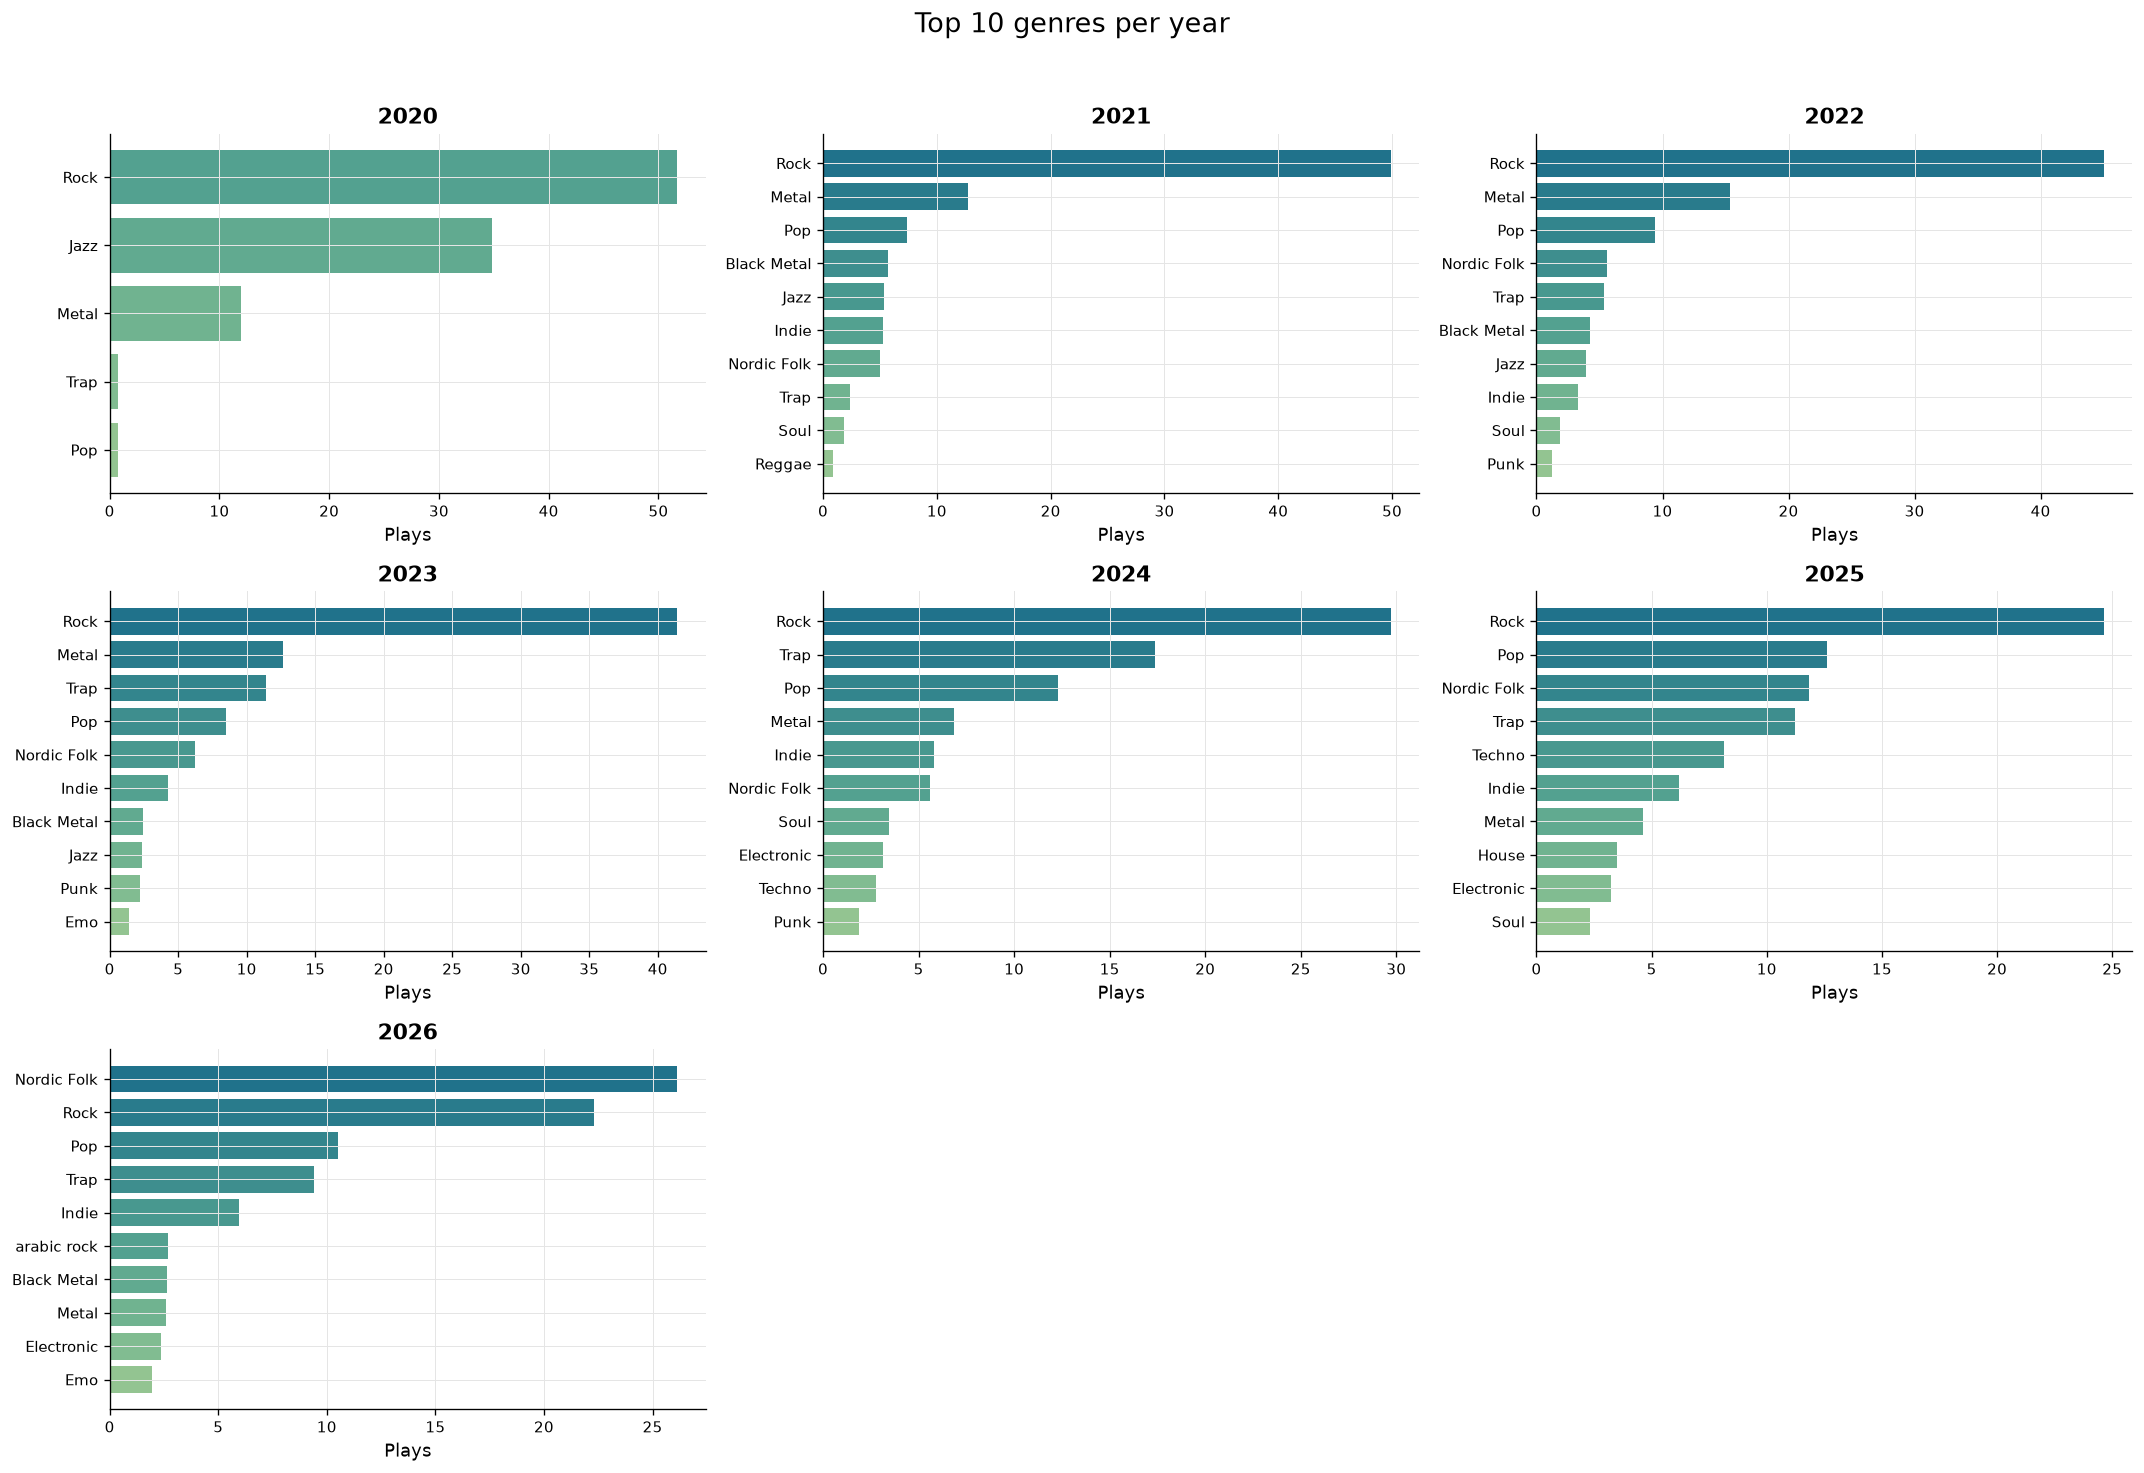

In [ ]:

years = sorted(genre_rank["calendar_year"].unique())
n_years = len(years)
n_cols = 3
n_rows = int(np.ceil(n_years / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

palette = sns.color_palette("crest", 15)

for i, year in enumerate(years):
    ax = axes[i]
    year_data = (
        genre_rank[genre_rank["calendar_year"] == year]
        .nlargest(10, "pct")
        .sort_values("pct")
    )
    ax.barh(year_data["genre_bucket"], year_data["pct"], color=palette)
    ax.set_title(str(year))
    ax.set_xlabel("Plays")

for j in range(n_years, len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Top 10 genres per year", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

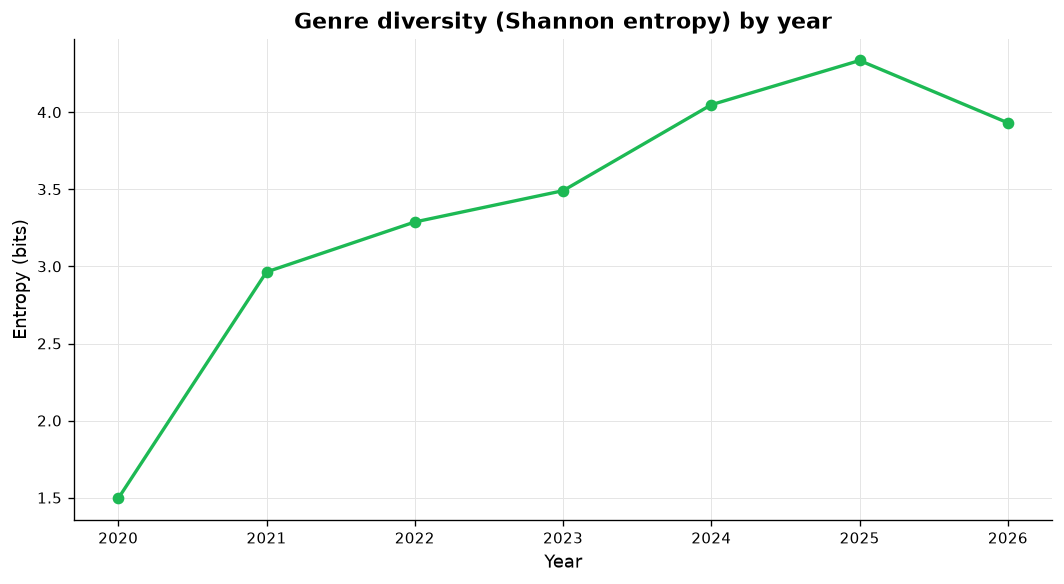

In [30]:
def shannon_entropy(counts):
    p = counts / counts.sum()
    return (p * np.log2(1/p)).sum()

entropy_by_year = (
    df3.groupby("calendar_year")["play_count"]
    .apply(shannon_entropy)
    .reset_index(name="genre_entropy")
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(entropy_by_year["calendar_year"], entropy_by_year["genre_entropy"],
        marker="o", color="#1DB954", linewidth=2)
ax.set_title("Genre diversity (Shannon entropy) by year")
ax.set_xlabel("Year")
ax.set_ylabel("Entropy (bits)")

plt.tight_layout()
plt.show()


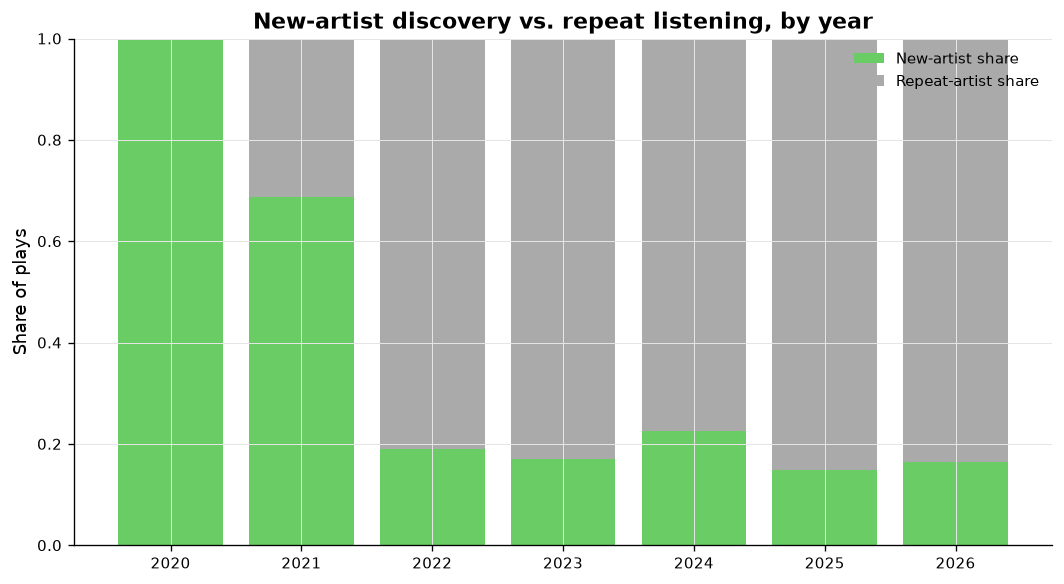

,year,new_artist_plays,repeat_artist_plays,total_plays,new_artist_share
0,2020,541,0,541,1.000000
1,2021,7190,3275,10465,0.687052
2,2022,1278,5455,6733,0.189811
3,2023,2354,11453,13807,0.170493
4,2024,3168,10821,13989,0.226464
5,2025,1512,8636,10148,0.148995
6,2026,825,4170,4995,0.165165


In [31]:
plays_year = query(
    "SELECT f.artist_id, d.calendar_year AS year, COUNT(*) AS plays "
    "FROM fact_listening_history f "
    "JOIN dim_date d ON d.date_key = f.date_key "
    "WHERE f.artist_id IS NOT NULL "
    "GROUP BY f.artist_id, d.calendar_year;"
)

first_heard = (
    plays_year.groupby("artist_id")["year"]
    .min()
    .reset_index(name="first_year_heard")
)

plays_year = plays_year.merge(first_heard, on="artist_id")
plays_year["is_new_artist_this_year"] = plays_year["year"] == plays_year["first_year_heard"]

discovery = (
    plays_year.groupby("year")
    .apply(lambda g: pd.Series({
        "new_artist_plays": g.loc[g["is_new_artist_this_year"], "plays"].sum(),
        "repeat_artist_plays": g.loc[~g["is_new_artist_this_year"], "plays"].sum(),
    }))
    .reset_index()
)
discovery["total_plays"] = discovery["new_artist_plays"] + discovery["repeat_artist_plays"]
discovery["new_artist_share"] = discovery["new_artist_plays"] / discovery["total_plays"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(discovery["year"].astype(str), discovery["new_artist_share"], color=C["green"], label="New-artist share")
ax.bar(discovery["year"].astype(str), 1 - discovery["new_artist_share"],
       bottom=discovery["new_artist_share"], color=C["grey"], label="Repeat-artist share")
ax.set_title("New-artist discovery vs. repeat listening, by year")
ax.set_ylabel("Share of plays")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

discovery

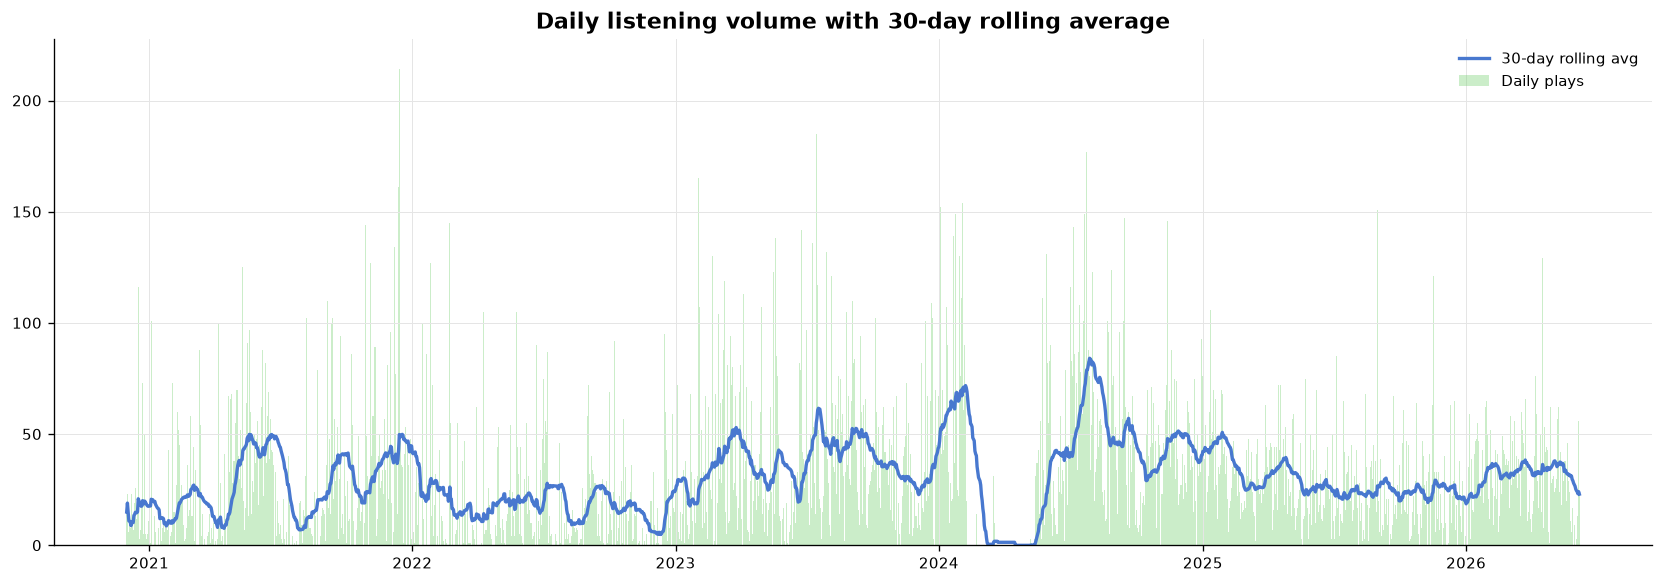

In [ ]:
daily = query(
    "SELECT played_at::date AS day, COUNT(*) AS track_count "
    "FROM fact_listening_history "
    "GROUP BY played_at::date "
    "ORDER BY 1;"
)
daily["day"] = pd.to_datetime(daily["day"])

full_range = pd.date_range(daily["day"].min(), daily["day"].max(), freq="D")
daily = daily.set_index("day").reindex(full_range, fill_value=0).rename_axis("day").reset_index()
daily["rolling_30d"] = daily["track_count"].rolling(30, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(daily["day"], daily["track_count"], color=C["green"], alpha=0.35, width=1.0, label="Daily plays")
ax.plot(daily["day"], daily["rolling_30d"], color=C["blue"], linewidth=2, label="30-day rolling avg")
ax.set_title("Daily listening volume with 30-day rolling average")
ax.legend()
plt.tight_layout()
plt.show()